In [2]:
pip install -e ..

Obtaining file:///home/sagar/winogender_contextuality
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for winogender_contextuality (pyproject.toml) ... done
  Created wheel for winogender_contextuality: filename=winogender_contextuality-0.0.1-py3-none-any.whl size=4382 sha256=ddef975118f968c890056b907aac4e7780b7c74e28e64f8ba5615caafc834a5e
  Stored in directory: /tmp/pip-ephem-wheel-cache-1hyr_gf4/wheels/f6/b9/38/03ac5a5ccd63b90faa34c1614fd3e708a9c34ab8edb44270e9
Successfully built winogender_contextuality
  Attempting uninstall: winogender_contextuality
    Found existing installation: winogender_contextuality 0.0.1
    Uninstalling winogender_contextuality-0.0.1:
      Successfully uninstalled winogender_contextuality-0.0.1
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from collections import defaultdict, Counter, OrderedDict
from tqdm.notebook import tqdm
from sklearn.feature_selection import mutual_info_classif
from matplotlib.patches import Patch
from scipy.stats import spearmanr
import seaborn as sns
from scipy.stats import fisher_exact
from itertools import combinations
import joypy
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from winogender_contextuality.utils import *
from winogender_contextuality.modeling.contextuality import *
from winogender_contextuality.modeling.analysis import *
from winogender_contextuality.config import * 

2025-12-14 20:22:45.697 | INFO     | winogender_contextuality.config:<module>:13 - PROJ_ROOT path is: /home/sagar/winogender_contextuality
2025-12-14 20:22:45.699 | INFO     | winogender_contextuality.config:<module>:17 - DATA_ROOT path is: /data_users1/sagar/winogender_contextuality


# Constants

In [4]:
max_idx = 180

In [5]:
case_index = {
    "$NOM_PRONOUN": 0,
    "$POSS_PRONOUN": 1,
    "$ACC_PRONOUN": 2
}

In [6]:
case_pronouns = {
    "$NOM_PRONOUN": ['he', 'she'],
    "$POSS_PRONOUN": ['his', 'her'],
    "$ACC_PRONOUN": ['him', 'her']
}

In [7]:
gender_pronouns = {
    'm': ['he', 'him', 'his'],
    'f': ['she', 'her', 'her']
}

# Functions

In [8]:
def primed_completion_differences_null(data: list[Measurement],
                                  mode: str,
                                  max_index: int = 60,
                                  CIs: bool = False):
    """
    Plots the probability of female pronoun generation for each sentence pair and its reverse.

    :param data: list of Measurement objects (or equivalently structured dictionaries)
    :param mode: 'internal' or 'generation'
    :param max_index: maximum index in data (last index is thrown away)
    :param plot: whether to plot results

    :returns: list of tuples with (unprimed fpronoun prob, mprimed fpronoun production prob, fprimed fpronoun production prob)
    """

    differences = []
    ci_list = []

    if mode == 'internal':
        prob_func = get_internal_probs
    elif mode == 'generation':
        prob_func = get_generation_probs
    else:
        raise AttributeError

    for idx in tqdm(range(max_index)):
        all_index_data = get_index(idx, data)

        # Lists
        null_1 = get_sent_order(["null_0", 0], all_index_data)
        null_2 = get_sent_order(["null_1", 0], all_index_data)


        # Probabilities
        p_null_1 = prob_func(null_1)
        p_null_2 = prob_func(null_2)

        try: 
            differences.append((p_null_1, p_null_2))
        except ValueError:
            print(null_1, null_2)

        if CIs:
            if mode == 'internal':
                raise ValueError("No CIs around internal logits.")
                
            ci_null_1 = get_generation_cis(null_1)
            ci_null_2 = get_generation_cis(null_2)
    
            try: 
                ci_list.append((ci_null_1, ci_null_2))
            except ValueError:
                print(ci_null_1, ci_null_2)

    if CIs:
        return differences, ci_list
    else:
        return differences

In [9]:
def primed_completion_differences(data: list[Measurement],
                                  mode: str,
                                  max_index: int = 60,
                                  CIs: bool = False,
                                  plot: bool = False):
    """
    Plots the probability of female pronoun generation for each sentence pair and its reverse.

    :param data: list of Measurement objects (or equivalently structured dictionaries)
    :param mode: 'internal' or 'generation'
    :param max_index: maximum index in data (last index is thrown away)
    :param plot: whether to plot results

    :returns: list of tuples with (unprimed fpronoun prob, mprimed fpronoun production prob, fprimed fpronoun production prob)
    """

    differences = []
    ci_list = []

    if mode == 'internal':
        prob_func = get_internal_probs
    elif mode == 'generation':
        prob_func = get_generation_probs
    else:
        raise AttributeError

    for idx in tqdm(range(max_index)):
        all_index_data = get_index(idx, data)

        # Lists
        unprimed_1 = get_sent_order([0, 1], get_single_sentences(all_index_data))
        unprimed_2 = get_sent_order([1, 0], get_single_sentences(all_index_data))

        primed_m1 = get_sent_order([0, 1], get_filled_pnoun(0, all_index_data))
        primed_f1 = get_sent_order([0, 1], get_filled_pnoun(1, all_index_data))
        primed_m2 = get_sent_order([1, 0], get_filled_pnoun(0, all_index_data))
        primed_f2 = get_sent_order([1, 0], get_filled_pnoun(1, all_index_data))


        # Probabilities
        p_unprimed_1 = prob_func(unprimed_1)
        p_unprimed_2 = prob_func(unprimed_2)

        p_primed_m1 = prob_func(primed_m1)
        p_primed_f1 = prob_func(primed_f1)
        p_primed_m2 = prob_func(primed_m2)
        p_primed_f2 = prob_func(primed_f2)

        tup1 = (p_unprimed_1, p_primed_m1, p_primed_f1)
        tup2 = (p_unprimed_2, p_primed_m2, p_primed_f2)

        try: 
            differences.append(tup1)
            differences.append(tup2)
        except ValueError:
            print(tup1, tup2)

        if CIs:
            if mode == 'internal':
                raise ValueError("No CIs around internal logits.")
                
            ci_unprimed_1 = get_generation_cis(unprimed_1)
            ci_unprimed_2 = get_generation_cis(unprimed_2)
    
            ci_primed_m1 = get_generation_cis(primed_m1)
            ci_primed_f1 = get_generation_cis(primed_f1)
            ci_primed_m2 = get_generation_cis(primed_m2)
            ci_primed_f2 = get_generation_cis(primed_f2)
    
            ci_tup1 = (ci_unprimed_1, ci_primed_m1, ci_primed_f1)
            ci_tup2 = (ci_unprimed_2, ci_primed_m2, ci_primed_f2)
    
            try: 
                ci_list.append(ci_tup1)
                ci_list.append(ci_tup2)
            except ValueError:
                print(ci_tup1, ci_tup2)
            

    if plot:
        fig, ax = plt.subplots(figsize=(10, 4))
        pruned_differences = [(n,t) for n,t in enumerate(differences) if is_valid_tuple(t)]
        collected_indices = [p[0] for p in pruned_differences]
        
        ax.plot(collected_indices, [p[1][0][1] for p in pruned_differences], label='unprimed', marker='x',
                linestyle='None', color='gray',
                markersize=5)
        
        ax.plot(collected_indices, [p[1][1][1] for p in pruned_differences], label='m primed', marker='o',
                linestyle='None', color='#E69F00',
                markersize=5)
        
        ax.plot(collected_indices, [p[1][2][1] for p in pruned_differences], label='f primed', marker='o',
                linestyle='None', color='#009E73',
                markersize=5)
            
        ax.legend()
        
        for subidx in collected_indices:
            try:
                min_idx, med_idx, max_idx = np.argsort([i[1] for i in differences[subidx]])
            except IndexError:
                continue

            if med_idx != 0:
                color = 'red'
            elif min_idx != 2:
                color = '#0072B2'
            else:
                color = 'gray'
                
            lb = differences[subidx][min_idx][1]
            ub = differences[subidx][max_idx][1]
            ax.vlines(subidx, ymin=lb, ymax=ub, alpha=0.5, color=color, linewidth=0.7)

        ax.set_xticks([])

    if CIs:
        return differences, ci_list
    else:
        return differences

In [10]:
def create_feature_table(index: int, 
                         data: list[Measurement] | list[dict],
                         features_df: pd.DataFrame):

    """
    Creates a DataFrame with columns [Measurement, Role, GPrime, POrder] for a *pair of sentences* using measurements provided. 

    ONLY OUTPUTS PRIMED INSTANCES.

    :param ratio: whether to exclude instances where target role has no ratio.

    :param data: List of Measurements (or equivalent dictionaries) 

    """

    fwd_list = get_sent_order([0,1],get_index(index,data, filter_none=True))
    bwd_list = get_sent_order([1,0],get_index(index,data, filter_none=True))

    forward_index = 2 * index
    reverse_index = 2 * index + 1

    forward_occ = features_df["role"][forward_index]
    reverse_occ = features_df["role"][reverse_index]

    forward_role = features_df["role_type"][forward_index]
    reverse_role = features_df["role_type"][reverse_index]

    forward_case = case_index[features_df["pronoun_type"][forward_index]]
    reverse_case = case_index[features_df["pronoun_type"][reverse_index]]

    forward_stereo = features_df["stereotype"][forward_index]
    reverse_stereo = features_df["stereotype"][reverse_index]

    fwd_prime_list = [str(m['context']['pnoun_order'][0]) for m in fwd_list]
    bwd_prime_list = [str(m['context']['pnoun_order'][0]) for m in bwd_list]

    fwd_measurement_list = [m['measurement']['BLANK'] for m in fwd_list if m['measurement']['BLANK'] is not None]
    bwd_measurement_list = [m['measurement']['BLANK'] for m in bwd_list if m['measurement']['BLANK'] is not None]

    fwd_measurement_pnoun_order = [str(m['context']['pnoun_order'][1]) for m in fwd_list]
    bwd_measurement_pnoun_order = [str(m['context']['pnoun_order'][1]) for m in bwd_list]

    measurements_df = pd.DataFrame(data={
        'Measurement': fwd_measurement_list + bwd_measurement_list, 
        'Role': [forward_occ] * len(fwd_list) + [reverse_occ]*len(bwd_list),
        'Role_Type': [forward_role] * len(fwd_list) + [reverse_role]*len(bwd_list),
        'Case': [forward_case] * len(fwd_list) + [reverse_case]*len(bwd_list),
        'Stereotype': [forward_stereo] * len(fwd_list) + [reverse_stereo]*len(bwd_list),
        'Prime': fwd_prime_list + bwd_prime_list,
        'Order': fwd_measurement_pnoun_order + bwd_measurement_pnoun_order
    })

    measurements_df["X"] = (measurements_df["Measurement"].isin(gender_pronouns['f'])).astype(int)
    measurements_df["y_role_type"] = (measurements_df["Role_Type"] == "occupation").astype(int)
    measurements_df["y_prime"] = (measurements_df["Prime"].isin(gender_pronouns['f'])).astype(int)
    measurements_df["y_stereo"] = measurements_df["Stereotype"]
    measurements_df["y_order"] = (measurements_df["Order"]).astype(int)
    measurements_df["y_primed"] = [i != 'None' for i in measurements_df["Prime"]]
    measurements_df["y_case"] = (measurements_df["Case"]).astype(int)

    return measurements_df
    
    

In [11]:
def get_mi_arr(data: list[dict] | list[Measurement],
               features_df: pd.DataFrame,
               role_type: bool = True,
               prime: bool = True,
               primed_status: bool = True,
               stereo: bool = True,
               case: bool = True,
               order: bool = True,
               include_unprimed = True, 
               include_primed = True,
               max_index: int = 180):
    """
    :param ratio: True removes any indices for whom
    """

    indices = []
    MIs = []

    for idx in tqdm(range(max_index)):
        
        df = create_feature_table(idx, data, features_df)

        if stereo:
            # If measuring stereotype dependence, drop instances without stereotype collected
            df = df[~np.isnan(df["y_stereo"])]

        if not include_unprimed:
            df = df[df["y_primed"]]

        if not include_primed:
            df = df[~df["y_primed"]]
            

        disc_columns = []
        cont_columns = []
        if role:
            disc_columns.append("y_role_type")
        if prime:
            disc_columns.append("y_prime")
        if primed_status:
            disc_columns.append("y_primed")
        if order: 
            disc_columns.append("y_order")
        if case:
            disc_columns.append("y_case")
        if stereo:
            cont_columns.append("y_stereo")
        
            
        
        y = df["X"].to_numpy()

        try:
            mi = []
            if len(disc_columns) > 0:
                X_disc = df[disc_columns].to_numpy()
                mi_disc = mutual_info_classif(X_disc, y, discrete_features=True)
                mi.extend(mi_disc)
            if len(cont_columns):
                X_cont = df[cont_columns].to_numpy()
                mi_cont = mutual_info_classif(X_cont, y, discrete_features=False)
                mi.extend(mi_cont)
            MIs.append(mi)
            indices.append(idx)
        except ValueError:
            pass
            
    MI_arr = np.array(MIs)
    all_columns = disc_columns + cont_columns

    return indices, all_columns, MI_arr

In [12]:
def get_mi_df(data: list[dict] | list[Measurement],
              features_df: pd.DataFrame,
              role_type: bool = True,
              prime: bool = True,
              primed_status: bool = True,
              stereo: bool = True,
              case: bool = True,
              order: bool = True,
              include_unprimed = True, 
              include_primed = True,
              max_index: int = 180):
    """
    :param ratio: True removes any indices for whom
    """

    indices = []
    MIs = []

    for idx in tqdm(range(max_index)):
        
        df = create_feature_table(idx, data, features_df)

        if stereo:
            # If measuring stereotype dependence, drop instances without stereotype collected
            df = df[~np.isnan(df["y_stereo"])]

        if not include_unprimed:
            df = df[df["y_primed"]]

        if not include_primed:
            df = df[~df["y_primed"]]
            

        disc_columns = []
        cont_columns = []
        if role:
            disc_columns.append("y_role_type")
        if prime:
            disc_columns.append("y_prime")
        if primed_status:
            disc_columns.append("y_primed")
        if order: 
            disc_columns.append("y_order")
        if case:
            disc_columns.append("y_case")
        if stereo:
            cont_columns.append("y_stereo")
        
            
        
        y = df["X"].to_numpy()

        try:
            mi = []
            if len(disc_columns) > 0:
                X_disc = df[disc_columns].to_numpy()
                mi_disc = mutual_info_classif(X_disc, y, discrete_features=True)
                mi.extend(mi_disc)
            if len(cont_columns):
                X_cont = df[cont_columns].to_numpy()
                mi_cont = mutual_info_classif(X_cont, y, discrete_features=False)
                mi.extend(mi_cont)
            MIs.append(mi)
            indices.append(idx)
        except ValueError:
            pass
            
    MI_arr = np.array(MIs)
    all_columns = disc_columns + cont_columns

    out_df = pd.DataFrame(MI_arr, columns=all_columns, index=indices)

    return out_df

In [13]:
def get_contextuality_table(
        model_measurements: list[dict],
        default_pronoun: int = 1,  # 0 for male, 1 for female
        max_index: int = 180
) -> pd.DataFrame:
    indices = []

    mfirst_int = []
    ffirst_int = []

    mfirst_gen = []
    ffirst_gen = []

    for idx in tqdm(range(max_index)):

        try:

            # Internal
            mfirst_int_data = sentence_order_single_results(idx, model_measurements, pnoun_order=0, mode='internal')
            mfirst_int_dc = calculate_sentence_dc_fraction(mfirst_int_data, mode='internal')

            ffirst_int_data = sentence_order_single_results(idx, model_measurements, pnoun_order=1, mode='internal')
            ffirst_int_dc = calculate_sentence_dc_fraction(ffirst_int_data, mode='internal')

            # Generation
            mfirst_gen_data = sentence_order_single_results(idx, model_measurements, pnoun_order=0, mode='generation')
            mfirst_gen_dc = calculate_sentence_dc_fraction(mfirst_gen_data, mode='generation')

            ffirst_gen_data = sentence_order_single_results(idx, model_measurements, pnoun_order=1, mode='generation')
            ffirst_gen_dc = calculate_sentence_dc_fraction(ffirst_gen_data, mode='generation')



        except Exception as e:
            logger.error(f"Error calculating degree of contextuality for index {idx}: {e}")
            continue

        indices.append(idx)
        mfirst_int.append(mfirst_int_dc)
        ffirst_int.append(ffirst_int_dc)
        mfirst_gen.append(mfirst_gen_dc)
        ffirst_gen.append(ffirst_gen_dc)

    out_df = pd.DataFrame(data={
        "index": indices,
        "int_mfirst": mfirst_int,
        "int_ffirst": ffirst_int,
        "gen_mfirst": mfirst_gen,
        "gen_ffirst": ffirst_gen
    })

    return out_df


# Loading Data

## Raw WinoPron Templates

In [14]:
raw_templates = pd.read_csv(RAW_DATA_DIR/"new_templates.tsv", sep="\t")

## Stereotypes Dataset

In [15]:
stereo = pd.read_csv(RAW_DATA_DIR/"occupation_english_means_final.csv")

## WinoPron T=0.5

In [16]:
gpt_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_gpt-oss-20b_0.5_wp_k40.ndjson")
max_gpt = max([x["index"] for x in gpt_wp])
f"{len(gpt_wp)} Measuremenents"

'289600 Measuremenents'

In [17]:
phi_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_phi-4_0.5_wp_k40.ndjson")
max_phi = max([x["index"] for x in phi_wp])
f"{len(phi_wp)} Measuremenents"

'289967 Measuremenents'

In [18]:
llama1b_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Llama-3.2-1B-Instruct_0.5_1512241025.ndjson")
max_llama1b = max([x["index"] for x in llama1b_wp])
f"{len(llama1b_wp)} Measuremenents"

'1158400 Measuremenents'

In [19]:
llama8b_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Llama-3.1-8B-Instruct_0.5_wp_k40.ndjson")
max_llama8b = max([x["index"] for x in llama8b_wp])
f"{len(llama8b_wp)} Measuremenents"

'144800 Measuremenents'

In [20]:
qwen_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Qwen2.5-7B-Instruct_0.5_wp_k40.ndjson")
max_qwen = max([x["index"] for x in qwen_wp])
f"{len(qwen_wp)} Measuremenents"

'243200 Measuremenents'

In [21]:
#deep_wp -- need to fix template
#mistral_wp -- need to fix template
# qwq_wp -- need to fix template
winopron_results_05 = [gpt_wp, phi_wp, llama1b_wp, llama8b_wp, qwen_wp]

In [22]:
#'mistral'
#'deepseek'
#'qwq'
model_names = ['gpt', 'phi',  'llama1b', 'llama8b', 'qwen']

## WinoPron Null

## Creating a list of all sentences

In [23]:
winopron_pairs = pd.read_csv(INTERIM_DATA_DIR/"winopron_pairs.tsv", sep="\t")
winopron_pairs.head()

,template_1,differences_1,case_1,referent_1,template_2,differences_2,case_2,referent_2
0,The technician told the customer that BLANK co...,"['he', 'she']",$NOM_PRONOUN,customer,The technician told the customer that BLANK ha...,"['he', 'she']",$NOM_PRONOUN,technician
1,The technician had to call the customer for BL...,"['him', 'her']",$ACC_PRONOUN,customer,The technician had to call the customer for BL...,"['him', 'her']",$ACC_PRONOUN,technician
2,The customer told the technician that BLANK fr...,"['his', 'her']",$POSS_PRONOUN,customer,The customer told the technician that BLANK ch...,"['his', 'her']",$POSS_PRONOUN,technician
3,The taxpayer met with the accountant to find o...,"['he', 'she']",$NOM_PRONOUN,taxpayer,The taxpayer met with the accountant to find o...,"['he', 'she']",$NOM_PRONOUN,accountant
4,The taxpayer met with the accountant for BLANK...,"['him', 'her']",$ACC_PRONOUN,taxpayer,The taxpayer met with the accountant for BLANK...,"['him', 'her']",$ACC_PRONOUN,accountant


In [24]:
all_sentences_wp = pd.DataFrame()
all_templates = []
all_pnouns = []
all_referents = []
all_cases = []
for idx in winopron_pairs.index:
    for n in [1,2]:
        all_templates.append(winopron_pairs[f"template_{n}"][idx])
        all_pnouns.append(winopron_pairs[f"differences_{n}"][idx])
        all_referents.append(winopron_pairs[f"referent_{n}"][idx])
        all_cases.append(winopron_pairs[f"case_{n}"][idx])

all_sentences_wp['template'] = all_templates
all_sentences_wp['differences'] = all_pnouns
all_sentences_wp['referent'] = all_referents
all_sentences_wp['case'] = all_cases

In [25]:
all_sentences_wp.head()

,template,differences,referent,case
0,The technician told the customer that BLANK co...,"['he', 'she']",customer,$NOM_PRONOUN
1,The technician told the customer that BLANK ha...,"['he', 'she']",technician,$NOM_PRONOUN
2,The technician had to call the customer for BL...,"['him', 'her']",customer,$ACC_PRONOUN
3,The technician had to call the customer for BL...,"['him', 'her']",technician,$ACC_PRONOUN
4,The customer told the technician that BLANK fr...,"['his', 'her']",customer,$POSS_PRONOUN


In [26]:
#all_sentences_wp.to_csv(INTERIM_DATA_DIR/"all_sentences_wp.csv")

## Loading Null Data

In [27]:
# these must all be recollected

In [28]:
gpt_null = load_ndjson(INTERIM_DATA_DIR / "null_measurements_gpt-oss-20b_0.5_wp.ndjson")

In [29]:
phi_null = load_ndjson(INTERIM_DATA_DIR / "null_measurements_phi-4_0.5_wp.ndjson")

In [30]:
qwen_null = load_ndjson(INTERIM_DATA_DIR / "null_measurements_Qwen2.5-7B-Instruct_0.5_wp.ndjson")

In [31]:
llama8b_null = load_ndjson(INTERIM_DATA_DIR / "null_measurements_Llama-3.1-8B-Instruct_0.5_wp.ndjson")

In [32]:
llama1b_null = load_ndjson(INTERIM_DATA_DIR / "null_measurements_Llama-3.2-1B-Instruct_0.5_1552071125.ndjson")

In [33]:
all_null = [gpt_null, phi_null, qwen_null, llama8b_null, llama1b_null]

# Generation Differences

In [34]:
priming_labels = ['Unprimed', 'Masc Primed', 'Fem Primed']

In [35]:
all_gen_diffs = [primed_completion_differences(d, 
                                               mode='generation',
                                               max_index = max([x["index"] for x in d]),
                                               CIs = True
                                              )
                 for d in winopron_results_05]

 86%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 154/180 [00:33<00:05,  4.79it/s]

2025-12-14 20:24:29.972 | DEBUG    | winogender_contextuality.utils:get_generation_probs:256 - Likely no measurements found. Exception raised: list index out of range
2025-12-14 20:24:29.974 | DEBUG    | winogender_contextuality.utils:get_generation_probs:256 - Likely no measurements found. Exception raised: list index out of range
2025-12-14 20:24:29.977 | DEBUG    | winogender_contextuality.utils:get_generation_cis:286 - Likely no measurements found. Exception raised: list index out of range
2025-12-14 20:24:29.980 | DEBUG    | winogender_contextuality.utils:get_generation_cis:286 - Likely no measurements found. Exception raised: list index out of range


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [00:10<00:00, 17.83it/s]


## Individual Items

<ErrorbarContainer object of 3 artists>

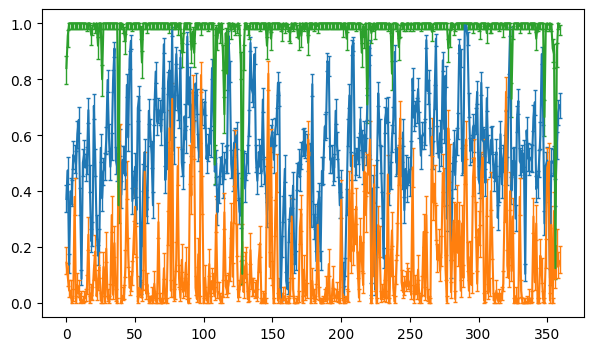

In [36]:
def clip_errs(lower, upper, min_val=0.0):
    lower = np.maximum(lower, min_val)
    upper = np.maximum(upper, min_val)
    return np.vstack([lower, upper])

test_model_results = all_gen_diffs[0] # 0 - GPT

plt.figure(figsize=(7, 4))

# Unprimed
unprimed_ps = np.array([i[0][1] for i in test_model_results[0]])
unprimed_cis = np.array([i[0][1] for i in test_model_results[1]])

lower_err = unprimed_ps - unprimed_cis[:, 0]
upper_err = unprimed_cis[:, 1] - unprimed_ps
yerr = clip_errs(lower_err, upper_err, 1e-12)

plt.errorbar(range(len(test_model_results[0])), unprimed_ps, yerr=yerr,
            elinewidth=1, capsize=1.5)

# Male Primed
mprimed_ps = np.array([i[1][1] for i in test_model_results[0]])
mprimed_cis = np.array([i[1][1] for i in test_model_results[1]])

lower_err_m = mprimed_ps - mprimed_cis[:, 0]
upper_err_m = mprimed_cis[:, 1] - mprimed_ps
yerr_m = clip_errs(lower_err_m, upper_err_m, 1e-12)

plt.errorbar(range(len(test_model_results[0])), mprimed_ps, yerr=yerr_m,
            elinewidth=1, capsize=1.5)

# Female Primed
findices = []
fprimed_ps = []
fprimed_cis = []
for i in range(len(test_model_results[0])):
    try: 
        fprimed_ps.append(test_model_results[0][i][2][1])
        fprimed_cis.append(test_model_results[1][i][2][1])
        findices.append(i)
    except TypeError:
        pass

findices = np.array(findices)
fprimed_ps = np.array(fprimed_ps)
fprimed_cis = np.array(fprimed_cis)


lower_err_f = fprimed_ps - fprimed_cis[:, 0]
upper_err_f = fprimed_cis[:, 1] - fprimed_ps
yerr_f = clip_errs(lower_err_f, upper_err_f, 1e-12)
plt.errorbar(findices, fprimed_ps, yerr=yerr_f,
            elinewidth=1, capsize=1.5)

## Average Across All Instances

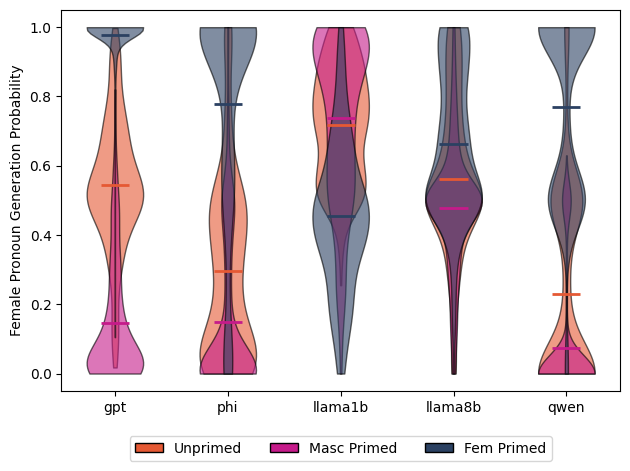

In [37]:
all_generation_probabilities = []
for n in range(3):
    all_priming_probs = []
    for model,_ in all_gen_diffs:
        fem_probs = []
        for x in model:
            try:
                fem_probs.append(x[n][1])
            except TypeError:
                pass
        all_priming_probs.append(fem_probs)
    all_generation_probabilities.append(all_priming_probs)


vp_colors = ['#E55934', '#C51B8A', '#2B4162']

for n in range(3):
    parts = plt.violinplot(all_generation_probabilities[n], 
                           showmeans=True, 
                           showextrema=False)
    for i, vp in enumerate(parts['bodies']):
        vp.set_facecolor(vp_colors[n])
        vp.set_edgecolor('black')
        vp.set_alpha(0.6)
    if 'cmeans' in parts and parts['cmeans'] is not None:
        parts['cmeans'].set_color(vp_colors[n])     # one color per violin
        parts['cmeans'].set_linewidth(2)
        parts['cmeans'].set_alpha(1)
        
plt.xticks(range(1, len(model_names)+1), model_names)

handles = [Patch(facecolor=vp_colors[i], edgecolor='black', label=priming_labels[i]) for i in range(len(vp_colors))]
plt.legend(handles=handles, 
           loc='upper center',          # place legend at top center of the box
           bbox_to_anchor=(0.5, -0.1),  # move it below the axes
           ncol=len(handles))  
plt.ylabel("Female Pronoun Generation Probability")
plt.tight_layout()
#plt.savefig(REPORTS_DIR/"figures"/"violin_plots_0.5_5models.pdf")

### Null Distributions

In [38]:
test_null = primed_completion_differences_null(gpt_null, mode='generation', max_index=360, CIs=True)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 360/360 [00:07<00:00, 50.24it/s]


In [39]:
all_null_gen_diffs = [primed_completion_differences_null(d, 
                                               mode='generation',
                                               max_index = max([x["index"] for x in d]),
                                               CIs = True
                                              )
                 for d in all_null]

  2%|██▊                                                                                                                                                                        | 6/361 [00:00<00:13, 25.43it/s]

2025-12-14 20:25:23.346 | DEBUG    | winogender_contextuality.utils:get_generation_probs:256 - Likely no measurements found. Exception raised: list index out of range
2025-12-14 20:25:23.349 | DEBUG    | winogender_contextuality.utils:get_generation_cis:286 - Likely no measurements found. Exception raised: list index out of range
2025-12-14 20:25:23.387 | DEBUG    | winogender_contextuality.utils:get_generation_probs:256 - Likely no measurements found. Exception raised: list index out of range
2025-12-14 20:25:23.390 | DEBUG    | winogender_contextuality.utils:get_generation_cis:286 - Likely no measurements found. Exception raised: list index out of range


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 361/361 [00:13<00:00, 26.14it/s]


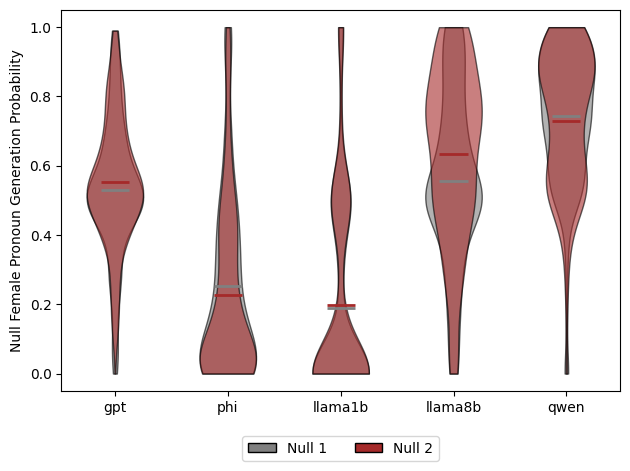

In [40]:
all_null_gen_probabilities = []
for n in range(2):
    all_priming_probs = []
    for model,_ in all_null_gen_diffs:
        fem_probs = []
        for x in model:
            try:
                fem_probs.append(x[n][1])
            except TypeError:
                pass
        all_priming_probs.append(fem_probs)
    all_null_gen_probabilities.append(all_priming_probs)

null_priming_labels = ["Null 1", "Null 2"]
null_vp_colors = ['grey', 'brown']

for n in range(2):
    parts = plt.violinplot(all_null_gen_probabilities[n], 
                           showmeans=True, 
                           showextrema=False)
    for i, vp in enumerate(parts['bodies']):
        vp.set_facecolor(null_vp_colors[n])
        vp.set_edgecolor('black')
        vp.set_alpha(0.6)
    if 'cmeans' in parts and parts['cmeans'] is not None:
        parts['cmeans'].set_color(null_vp_colors[n])     # one color per violin
        parts['cmeans'].set_linewidth(2)
        parts['cmeans'].set_alpha(1)
        
plt.xticks(range(1, len(model_names)+1), model_names)

null_handles = [Patch(facecolor=null_vp_colors[i], edgecolor='black', label=null_priming_labels[i]) for i in range(len(null_vp_colors))]
plt.legend(handles=null_handles, 
           loc='upper center',          # place legend at top center of the box
           bbox_to_anchor=(0.5, -0.1),  # move it below the axes
           ncol=len(handles))  
plt.ylabel("Null Female Pronoun Generation Probability")
plt.tight_layout()
#plt.savefig(REPORTS_DIR/"figures"/"violin_plots_0.5_5models.pdf")

### Joy plots

In [ ]:
for m, name in enumerate(model_names):
    context_dists = [all_generation_probabilities[i][m] for i in range(3)]
    null_dists = [all_null_gen_probabilities[i][m] for i in range(2)]
    fig_i, ax_i = joypy.joyplot(context_dists, #+ null_dists,
                 color=['#E55934', '#C51B8A', '#2B4162']#, 'None', 'None']
                               )
    fig_i.suptitle(name)
    ax_i[-1].set_xticks([])

## $\chi^2$

In [43]:
# DELETE WHEN RERUNNING
def get_generation_details(measurements: list[Measurement] | list[dict]) -> np.ndarray:
    """
    Returns successes and total number of measurements from each trial.

    :param measurements: list of Measurement objects (or equivelant dictionaries)
    :return: array of probabilities
    """
    # pronoun set is determined by the first measurement
    try:
        pnouns = measurements[0]['context']['pronouns_2']
    except Exception as e:
        logger.debug(f"Likely no measurements found. Exception raised: {e}")
        return np.nan

    # calculate empirical generation probabilities (remove anything not in the list of pronouns)
    generated_pnouns = []
    for m in measurements:
        try:
            generated_pnouns.append(m['measurement']['BLANK'])
        except Exception as e:
            logger.debug(f"Exception {e} raised for item {m}")
            pass
    generation_counter = Counter(generated_pnouns)
    generation_counter_clean = {k: generation_counter[k] for k in pnouns}
    num_valid_measurements = np.sum(list(generation_counter_clean.values()))
    return generation_counter_clean, num_valid_measurements

In [44]:
list(combinations([1,2,3], 2))

[(1, 2), (1, 3), (2, 3)]

In [45]:
# Turn this into a collection of 2x2 Fisher's instead
all_model_fishers = []
for model in winopron_results_05:
    model_results = []
    indices_collected = []
    for idx in tqdm(range(180)): # this may have to change to max indices

        try: 
            d_fwd, ct_fwd = get_generation_details(get_sent_order([0, 1], get_single_sentences(get_index(idx, model))))
            dm_fwd, ctm_fwd = get_generation_details(get_sent_order([0, 1], get_filled_pnoun(0, get_index(idx, model))))
            df_fwd, ctf_fwd = get_generation_details(get_sent_order([0, 1], get_filled_pnoun(1, get_index(idx, model))))
            index = 2 * idx
            indices_collected.append(index)
        except TypeError:
            pass

        try: 
            d_bwd, ct_bwd = get_generation_details(get_sent_order([0, 1], get_single_sentences(get_index(idx, model))))
            dm_bwd, ctm_bwd = get_generation_details(get_sent_order([0, 1], get_filled_pnoun(0, get_index(idx, model))))
            df_bwd, ctf_bwd = get_generation_details(get_sent_order([0, 1], get_filled_pnoun(1, get_index(idx, model))))
            index = 2 * idx + 1
            indices_collected.append(index)

        except TypeError:
            pass

        # Change to Fisher's exact test comparing 2x2 tables
        fwd_dicts = [d_fwd, dm_fwd, df_fwd]
        bwd_dicts = [d_bwd, dm_bwd, df_bwd]

        fwd_combs = combinations(fwd_dicts, 2)
        bwd_combs = combinations(bwd_dicts, 2)

        comb_order = ['unprimed_mprimed', 'unprimed_fprimed', 'mprimed_fprimed']
        
        sent_results = []
        for direction in [fwd_combs, bwd_combs]:
            for n, pair in enumerate(direction):
                d1, d2 = pair
                # find masc and fem pronouns in keys
                d1_fem = [v for k,v in d1.items() if k in gender_pronouns['f']][0]
                d1_masc = [v for k,v in d1.items() if k in gender_pronouns['m']][0]
                d2_fem = [v for k,v in d2.items() if k in gender_pronouns['f']][0]
                d2_masc = [v for k,v in d2.items() if k in gender_pronouns['m']][0]
    
                table = np.array([[d1_fem, d2_fem], 
                                  [d1_masc, d2_masc]])
    
                odds_ratio, p_value = fisher_exact(table)
    
                sent_results.append((index, comb_order[n],odds_ratio, p_value))

        model_results.extend(sent_results)
    all_model_fishers.append(model_results)
    

 85%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                         | 153/180 [03:00<00:31,  1.16s/it]

2025-12-14 13:42:45.115 | DEBUG    | __main__:get_generation_details:13 - Likely no measurements found. Exception raised: list index out of range


 86%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 154/180 [03:00<00:30,  1.16s/it]

2025-12-14 13:42:45.689 | DEBUG    | __main__:get_generation_details:13 - Likely no measurements found. Exception raised: list index out of range


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [00:53<00:00,  3.34it/s]


In [46]:
unprimed_mprimed_counts = [
    len([idx for idx in model if idx[1] == 'unprimed_mprimed' and idx[3] < 0.05])/len([idx for idx in model if idx[1] == 'unprimed_mprimed']) 
    for model in all_model_fishers
]

unprimed_fprimed_counts = [
    len([idx for idx in model if idx[1] == 'unprimed_fprimed' and idx[3] < 0.05])/len([idx for idx in model if idx[1] == 'unprimed_fprimed']) 
    for model in all_model_fishers
]

mprimed_fprimed_counts = [
    len([idx for idx in model if idx[1] == 'mprimed_fprimed' and idx[3] < 0.05])/len([idx for idx in model if idx[1] == 'mprimed_fprimed']) 
    for model in all_model_fishers
]
unprimed_mprimed_counts, unprimed_fprimed_counts, mprimed_fprimed_counts

([0.9388888888888889,
  0.7222222222222222,
  0.8777777777777778,
  0.4722222222222222,
  0.4111111111111111],
 [0.9888888888888889,
  0.8666666666666667,
  0.8944444444444445,
  0.6,
  0.8666666666666667],
 [0.9944444444444445,
  0.9,
  0.8888888888888888,
  0.6222222222222222,
  0.8833333333333333])

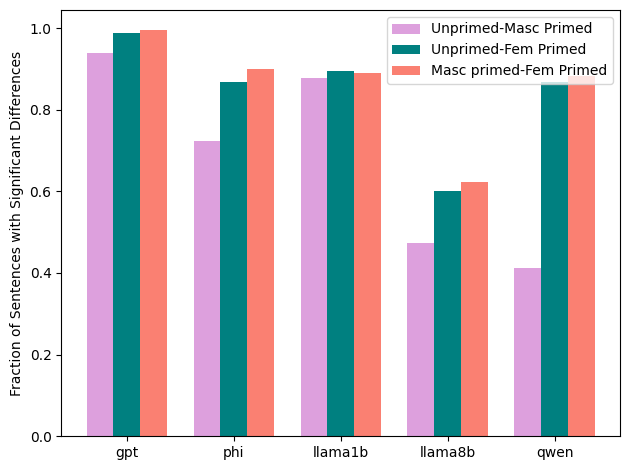

In [47]:
barx = np.arange(len(model_names))            # the label locations
width = 0.25                                # width of each bar

plt.bar(barx - width, unprimed_mprimed_counts,  width=width, label='Unprimed-Masc Primed', color="#DDA0DD")
plt.bar(barx,         unprimed_fprimed_counts, width=width, label='Unprimed-Fem Primed', color="#008080")
plt.bar(barx + width, mprimed_fprimed_counts,  width=width, label='Masc primed-Fem Primed', color="#FA8072")

plt.xticks(barx, model_names)
plt.legend()
plt.ylabel("Fraction of Sentences with Significant Differences")
plt.tight_layout()
#plt.savefig(FIGURES_DIR / "fishers_exact_5models.pdf")

### Null Correlations

# Internal Differences

## Average Across All Instances

 85%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                         | 153/180 [00:34<00:05,  4.58it/s]/home/sagar/miniconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/sagar/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [00:10<00:00, 17.82it/s]


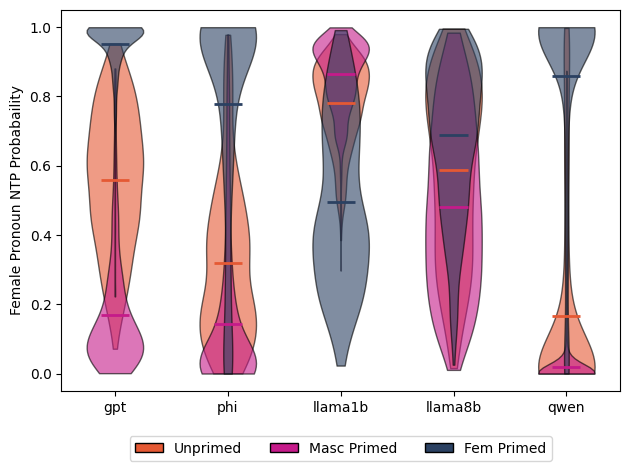

In [48]:
all_int_diffs = [primed_completion_differences(d, mode='internal',
                                              max_index = max([x["index"] for x in d])
                                              )
                 for d in winopron_results_05]

all_internal_probabilities = []
for n in range(3):
    all_priming_probs = []
    for model in all_int_diffs:
        fem_probs = []
        for x in model:
            try:
                fem_probs.append(x[n][1])
            except IndexError:
                pass
        all_priming_probs.append(fem_probs)
    all_internal_probabilities.append(all_priming_probs)

vp_colors = ['#E55934', '#C51B8A', '#2B4162']

for n in range(3):
    parts = plt.violinplot(all_internal_probabilities[n], 
                           showmeans=True, 
                           showextrema=False)
    for i, vp in enumerate(parts['bodies']):
        vp.set_facecolor(vp_colors[n])
        vp.set_edgecolor('black')
        vp.set_alpha(0.6)
    if 'cmeans' in parts and parts['cmeans'] is not None:
        parts['cmeans'].set_color(vp_colors[n])     # one color per violin
        parts['cmeans'].set_linewidth(2)
        parts['cmeans'].set_alpha(1)
        
plt.xticks(range(1, len(model_names)+1), model_names)

handles = [Patch(facecolor=vp_colors[i], edgecolor='black', label=priming_labels[i]) for i in range(len(vp_colors))]
plt.legend(handles=handles, 
           loc='upper center',          # place legend at top center of the box
           bbox_to_anchor=(0.5, -0.1),  # move it below the axes
           ncol=len(handles))  
plt.ylabel("Female Pronoun NTP Probabaility")
plt.tight_layout()
#plt.savefig(REPORTS_DIR/"figures"/"violin_plots_0.5_5models.pdf")

# Correlations with Cultural Biases

## Data Prep

In [49]:
raw_templates.head()

,occupation(0),other-participant(1),answer,pronoun_type,template,single_version
0,technician,customer,1,$NOM_PRONOUN,The $OCCUPATION told the $PARTICIPANT that $NO...,The $PARTICIPANT was told that $NOM_PRONOUN co...
1,technician,customer,0,$NOM_PRONOUN,The $OCCUPATION told the $PARTICIPANT that $NO...,The $OCCUPATION said that $NOM_PRONOUN had com...
2,technician,customer,1,$ACC_PRONOUN,The $OCCUPATION had to call the $PARTICIPANT f...,The $PARTICIPANT received a call for $ACC_PRON...
3,technician,customer,0,$ACC_PRONOUN,The $OCCUPATION had to call the $PARTICIPANT f...,The $OCCUPATION called for $ACC_PRONOUN to con...
4,technician,customer,1,$POSS_PRONOUN,The $PARTICIPANT told the $OCCUPATION that $PO...,The $PARTICIPANT said that $POSS_PRONOUN fridg...


In [50]:
stereo.set_index('occupation', inplace=True, drop=True)
stereo.head()

,matched_role_from_appendix_b,english_mean
occupation,,
hygienist,dentalhygienists,0.57
worker,construction workers,0.19
clerk,clerks,0.42
officer,NaN,0.36
machinist,heavy equipment operators,0.15


In [51]:
# Now, taking the data from raw_templates and creating a DF with the index, missing role, pronoun type, stereotype, occupational or not
roles = []
role_types = []
for idx in raw_templates.index:
    answer = raw_templates["answer"][idx]
    if answer == 0:
        role = raw_templates["occupation(0)"][idx]
        role_type = "occupation"
    else:
        role = raw_templates["other-participant(1)"][idx]
        role_type = "participant"
        
    roles.append(role)
    role_types.append(role_type)
    

all_features = pd.DataFrame(data={"role": roles, "role_type": role_types})
all_features["stereotype"] = [stereo["english_mean"][role] for role in roles]
all_features["pronoun_type"] = raw_templates["pronoun_type"]
all_features["template"] = raw_templates["template"]
all_features.head()

,role,role_type,stereotype,pronoun_type,template
0,customer,participant,0.58,$NOM_PRONOUN,The $OCCUPATION told the $PARTICIPANT that $NO...
1,technician,occupation,0.35,$NOM_PRONOUN,The $OCCUPATION told the $PARTICIPANT that $NO...
2,customer,participant,0.58,$ACC_PRONOUN,The $OCCUPATION had to call the $PARTICIPANT f...
3,technician,occupation,0.35,$ACC_PRONOUN,The $OCCUPATION had to call the $PARTICIPANT f...
4,customer,participant,0.58,$POSS_PRONOUN,The $PARTICIPANT told the $OCCUPATION that $PO...


In [52]:
all_features_wstereo = all_features[~np.isnan(all_features["stereotype"])]

In [53]:
print(f"Collected gender stereotypes for {len(all_features_wstereo)} out of {len(all_features)} sentences.")

Collected gender stereotypes for 279 out of 360 sentences.


## Testing Correlations

In [54]:
# now do this for all models and for all primings
# also do if for internal logits
# Ideally, we see significant correlations only in the unprimed case, but these vanish in primed cases

In [55]:
len(all_gen_diffs[3][0])

360

### Generation

#### Unprimed

In [56]:
unprimed_spearmans = []
unprimed_pvals = []

for n,model in enumerate(winopron_results_05):
    corr_df = pd.DataFrame()
    corr_df["stereotype"] = all_features["stereotype"]
    corr_df["fem_prob"] = [x[0][1] for x in all_gen_diffs[n][0]]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    unprimed_spearmans.append(corr)
    unprimed_pvals.append(p)

#### Male Primed

In [57]:
mprimed_spearmans = []
mprimed_pvals = []

for n,model in enumerate(winopron_results_05):
    corr_df = pd.DataFrame()
    corr_df["stereotype"] = all_features["stereotype"]
    corr_df["fem_prob"] = [x[1][1] for x in all_gen_diffs[n][0]]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    mprimed_spearmans.append(corr)
    mprimed_pvals.append(p)

#### Female Primed

In [58]:
fprimed_spearmans = []
fprimed_pvals = []

for n,model in enumerate(winopron_results_05):
    corr_df = pd.DataFrame()
    fem_probs = []
    fem_idxs = []
    for i,x in enumerate(all_gen_diffs[n][0]):
        try:
            fem_probs.append(x[2][1])
            fem_idxs.append(i)
        except TypeError:
            pass
    corr_df["fem_prob"] = fem_probs
    corr_df["stereotype"] = all_features["stereotype"][fem_idxs]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    fprimed_spearmans.append(corr)
    fprimed_pvals.append(p)

#### Plotting 

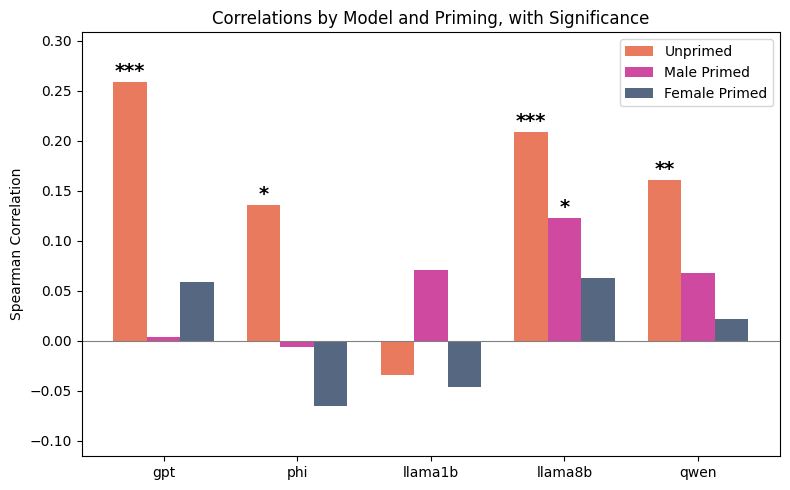

In [59]:
# --- Plot setup ---
corr_colors = {
    'unprimed': '#E55934',   
    'mprimed':  '#C51B8A',
    'fprimed':  '#2B4162'   
}

x = np.arange(len(winopron_results_05))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width, unprimed_spearmans, width, label='Unprimed', color=corr_colors['unprimed'], alpha=0.8)
bars2 = ax.bar(x, mprimed_spearmans, width, label='Male Primed', color=corr_colors['mprimed'], alpha=0.8)
bars3 = ax.bar(x + width, fprimed_spearmans, width, label='Female Primed', color=corr_colors['fprimed'], alpha=0.8)

# --- Add significance asterisks ---
def annotate_significance(bars, pvals):
    for bar, p in zip(bars, pvals):
        height = bar.get_height()
        if p < 0.001:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.001, '***',
                ha='center', va='bottom',
                fontsize=14, fontweight='bold', color='black'
            )
        elif p < 0.01:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.001, '**',
                ha='center', va='bottom',
                fontsize=14, fontweight='bold', color='black'
            )
        elif p < 0.05:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.001, '*',
                ha='center', va='bottom',
                fontsize=14, fontweight='bold', color='black'
            )

min_height = min([min(unprimed_spearmans), min(mprimed_spearmans), min(fprimed_spearmans)])
max_height = max([max(unprimed_spearmans), max(mprimed_spearmans), max(fprimed_spearmans)])
            

annotate_significance(bars1, unprimed_pvals)
annotate_significance(bars2, mprimed_pvals)
annotate_significance(bars3, fprimed_pvals)

# --- Formatting ---
ax.set_ylabel('Spearman Correlation')
ax.set_title('Correlations by Model and Priming, with Significance')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=0)
ax.legend()
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_ylim(min_height - 0.05, max_height + 0.05)

# Tidy layout
plt.tight_layout()
#plt.savefig(REPORTS_DIR/"figures"/"spearman_correlations_0.5_models.pdf")
plt.show()

### Internal

In [60]:
unprimed_spearmans_int = []
unprimed_pvals_int = []

for n,model in enumerate(winopron_results_05):
    corr_df = pd.DataFrame()
    corr_df["stereotype"] = all_features["stereotype"]
    corr_df["fem_prob"] = [x[0][1] for x in all_int_diffs[n]]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    unprimed_spearmans_int.append(corr)
    unprimed_pvals_int.append(p)

In [61]:
mprimed_spearmans_int = []
mprimed_pvals_int = []

for n,model in enumerate(winopron_results_05):
    corr_df = pd.DataFrame()
    corr_df["stereotype"] = all_features["stereotype"]
    corr_df["fem_prob"] = [x[1][1] for x in all_int_diffs[n]]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    mprimed_spearmans_int.append(corr)
    mprimed_pvals_int.append(p)

In [62]:
fprimed_spearman_int = []
fprimed_pvals_int = []

for n,model in enumerate(winopron_results_05):
    corr_df = pd.DataFrame()
    fem_probs = []
    fem_idxs = []
    for i,x in enumerate(all_int_diffs[n]):
        try:
            fem_probs.append(x[2][1])
            fem_idxs.append(i)
        except IndexError:
            pass
    corr_df["fem_prob"] = fem_probs
    corr_df["stereotype"] = all_features["stereotype"][fem_idxs]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    fprimed_spearman_int.append(corr)
    fprimed_pvals_int.append(p)

In [63]:
unprimed_pvals_int, mprimed_pvals_int, fprimed_pvals_int

([np.float64(6.040834752158516e-08),
  np.float64(0.003742994651161635),
  np.float64(0.24280722447667374),
  np.float64(2.45278990128781e-06),
  np.float64(0.0006942881834861148)],
 [np.float64(0.5564796063904436),
  np.float64(0.678258983150539),
  np.float64(0.7448978238641928),
  np.float64(0.0015784307804413637),
  np.float64(0.4813146186559204)],
 [np.float64(0.11660960841419232),
  np.float64(0.29926670003451405),
  np.float64(0.32407485692102944),
  np.float64(0.28366087373433424),
  np.float64(0.7203664688054812)])


# Mutual Information

In [64]:
test_mi = get_mi_arr(gpt_wp, all_features)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [00:27<00:00,  6.65it/s]


In [65]:
test_mi_df = get_mi_df(gpt_wp, all_features)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [00:27<00:00,  6.65it/s]


<Axes: >

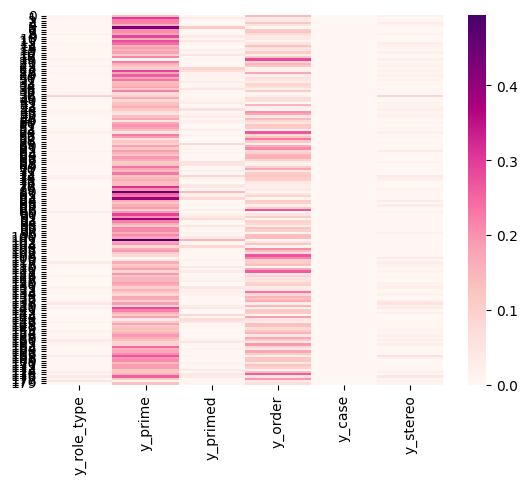

In [66]:
sns.heatmap(test_mi[2], cmap="RdPu", xticklabels=test_mi[1], yticklabels=test_mi[0])

<BarContainer object of 6 artists>

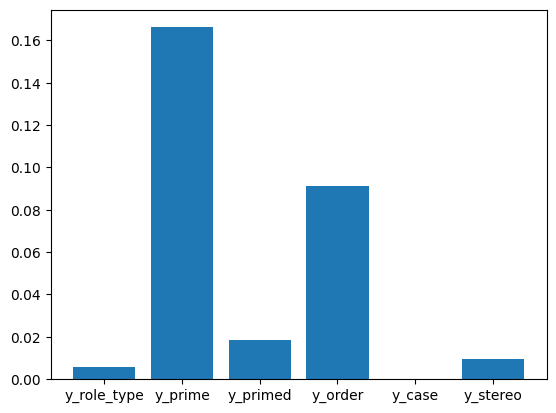

In [67]:
# Color these based on grouping
# [role_type, stereo], [prime, primed], [case, order]
plt.bar(test_mi[1], test_mi[2].mean(axis=0))

{'whiskers': [<matplotlib.lines.Line2D at 0x7ff28d221f90>,
 'caps': [<matplotlib.lines.Line2D at 0x7ff28d222210>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ff28d221e50>,
 'medians': [<matplotlib.lines.Line2D at 0x7ff28d222490>,
 'fliers': [<matplotlib.lines.Line2D at 0x7ff28d2225d0>,
 'means': []}

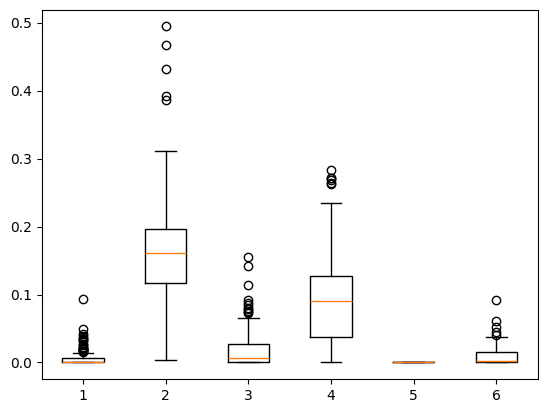

In [68]:
plt.boxplot(test_mi[2])

<Axes: >

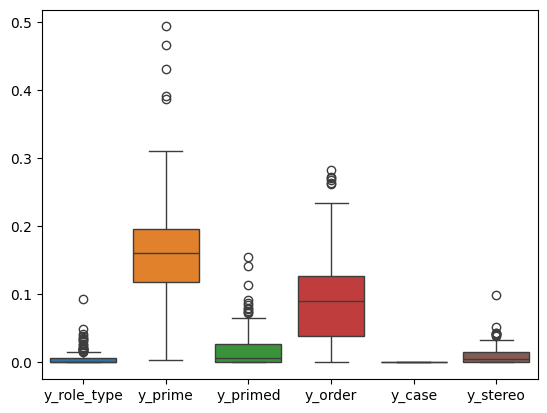

In [69]:
sns.boxplot(test_mi_df)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [00:26<00:00,  6.73it/s]


<BarContainer object of 6 artists>

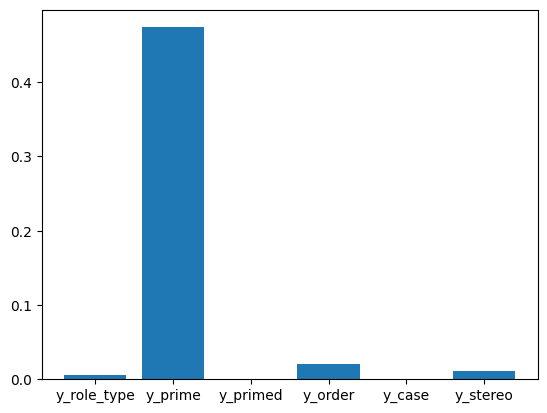

In [70]:
test_mi2 = get_mi_arr(gpt_wp, all_features, include_unprimed=False)
plt.bar(test_mi2[1], test_mi2[2].mean(axis=0))

{'whiskers': [<matplotlib.lines.Line2D at 0x7ff28d0334d0>,
 'caps': [<matplotlib.lines.Line2D at 0x7ff28d033750>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ff28d033390>,
 'medians': [<matplotlib.lines.Line2D at 0x7ff28d0339d0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7ff28d033b10>,
 'means': []}

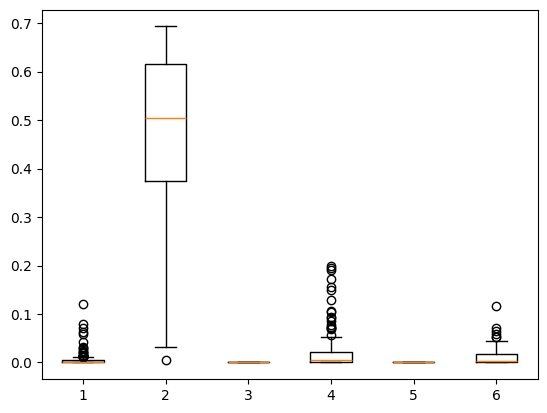

In [71]:
plt.boxplot(test_mi2[2])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [00:26<00:00,  6.67it/s]


<BarContainer object of 6 artists>

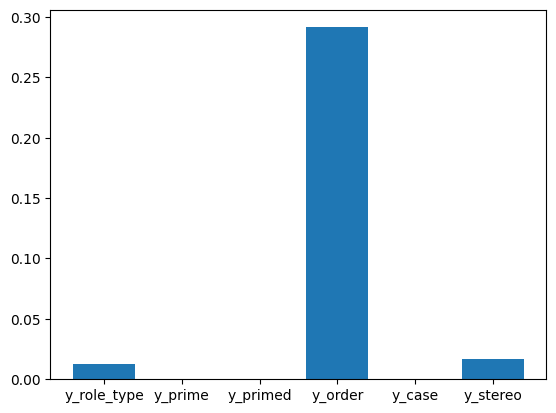

In [72]:
test_mi3 = get_mi_arr(gpt_wp, all_features, include_primed=False)
plt.bar(test_mi3[1], test_mi3[2].mean(axis=0))

{'whiskers': [<matplotlib.lines.Line2D at 0x7ff28cf95d10>,
 'caps': [<matplotlib.lines.Line2D at 0x7ff28cf95f90>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ff28cf95bd0>,
 'medians': [<matplotlib.lines.Line2D at 0x7ff28cf96210>,
 'fliers': [<matplotlib.lines.Line2D at 0x7ff28cf96350>,
 'means': []}

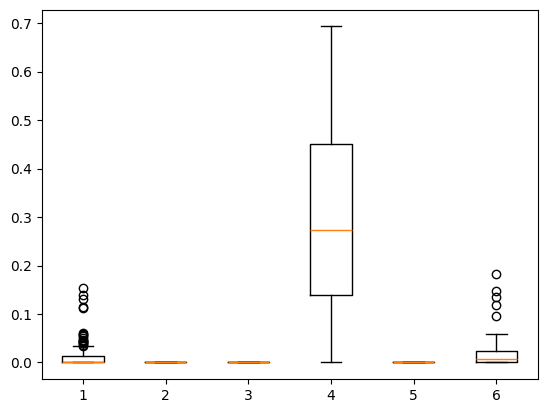

In [73]:
plt.boxplot(test_mi3[2])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [00:21<00:00,  8.39it/s]


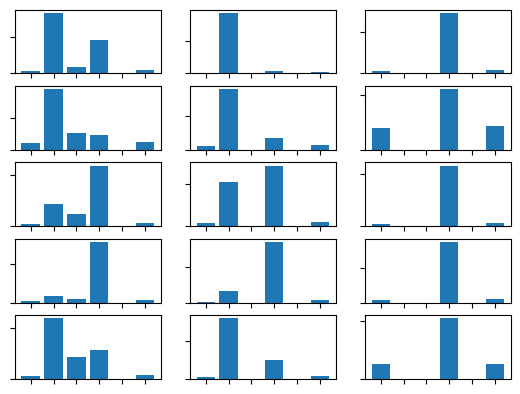

In [74]:
fig, axs = plt.subplots(5, 3)
for n, model in enumerate(winopron_results_05):
    all_mi = get_mi_arr(model, all_features)
    primed_mi = get_mi_arr(model, all_features, include_unprimed=False)
    unprimed_mi = get_mi_arr(model, all_features, include_primed=False)

    axs[n, 0].bar(all_mi[1], all_mi[2].mean(axis=0))
    axs[n, 1].bar(primed_mi[1], primed_mi[2].mean(axis=0))
    axs[n, 2].bar(unprimed_mi[1], unprimed_mi[2].mean(axis=0))

    axs[n, 0].set_xticklabels([])
    axs[n, 0].set_yticklabels([])
    axs[n, 1].set_xticklabels([])
    axs[n, 1].set_yticklabels([])
    axs[n, 2].set_xticklabels([])
    axs[n, 2].set_yticklabels([])

In [75]:
unprimed_order = ["y_role_type", "y_stereo", "y_case", "y_order"]
primed_order = ["y_prime", "y_role_type", "y_stereo", "y_case", "y_order"]

unprimed_mi_dfs = []
primed_mi_dfs = []
for n, model in enumerate(winopron_results_05):
    unprimed_df = get_mi_df(model, all_features, include_primed=False, primed_status=False, prime=False)
    primed_df = get_mi_df(model, all_features, include_unprimed=False, primed_status=False)

    unprimed_df = unprimed_df[unprimed_order]
    primed_df = primed_df[primed_order]

    unprimed_mi_dfs.append(unprimed_df)
    primed_mi_dfs.append(primed_df)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [00:21<00:00,  8.37it/s]


/tmp/ipykernel_1782738/501899676.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[n, 0].set_xticklabels(unprimed_labels, rotation=90)
/tmp/ipykernel_1782738/501899676.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[n, 1].set_xticklabels(primed_labels, rotation=90)


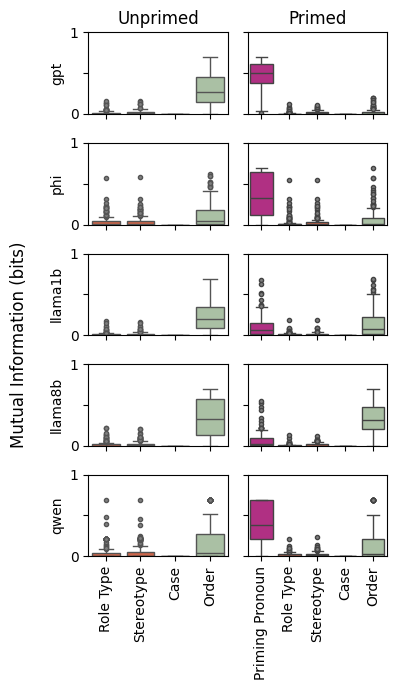

In [76]:
# Reorder the models, perhaps

fig, axs = plt.subplots(len(winopron_results_05), 2, sharey=True, figsize=(4, 7))

unprimed_labels = ["Role Type", "Stereotype", "Case", "Order"] # need to reorder so that order is last and groups hold
primed_labels = ["Priming Pronoun", "Role Type", "Stereotype", "Case", "Order"] # need to reorder so that ^^^ and priming is 1st

unprimed_colors = ["#E55934", "#E55934","#A7C4A0", "#A7C4A0"]
primed_colors   = ["#C51B8A", "#E55934", "#E55934","#A7C4A0", "#A7C4A0"]

for n, pair in enumerate(zip(unprimed_mi_dfs, primed_mi_dfs)):

    unprimed_df, primed_df = pair
    
    #sns.boxenplot(unprimed_df, ax=axs[n, 0], palette=unprimed_colors,
    #             flier_kws=dict(marker='o', s=10, linewidth=0, facecolor='gray'))
    #sns.boxenplot(primed_df, ax=axs[n, 1], palette=primed_colors,
    #             flier_kws=dict(marker='o', s=10, linewidth=0, facecolor='gray'))

    #sns.stripplot(unprimed_df, ax=axs[n, 0], size=3, palette=unprimed_colors)
    #sns.stripplot(primed_df, ax=axs[n, 1],size=3, palette=primed_colors)

    sns.boxplot(unprimed_df, ax=axs[n, 0], palette=unprimed_colors, 
                flierprops=dict(marker='o', markersize=3, linestyle='none', markerfacecolor='gray'))
    sns.boxplot(primed_df, ax=axs[n, 1], palette=primed_colors,
               flierprops=dict(marker='o', markersize=3, linestyle='none', markerfacecolor='gray'))

    #sns.barplot(unprimed_df.mean(axis=0), ax=axs[n, 0])
    #sns.barplot(primed_df.mean(axis=0), ax=axs[n, 1])

    axs[n, 1].set_yticklabels([])

    if n != len(winopron_results_05) - 1: 
        axs[n, 0].set_xticklabels([])
        axs[n, 1].set_xticklabels([])
    else:
        axs[n, 0].set_xticklabels(unprimed_labels, rotation=90)
        axs[n, 1].set_xticklabels(primed_labels, rotation=90)

    axs[n, 0].set_ylim(0,1)
    axs[n, 0].set_ylabel(model_names[n])

axs[0, 0].set_yticks([0, 0.5, 1], [0, None, 1])
axs[0, 0].set_title("Unprimed")
axs[0, 1].set_title("Primed")

fig.supylabel("Mutual Information (bits)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "MI_vertical_5models_box.pdf")

# Contextuality

In [77]:
# Create a raster/heatmap that diverges at 0 
# num_models x num_templates

In [78]:
# Are these calculations correct?
# Are they treating both directions at the same time?

def get_contextuality_table(
    model_measurements: list[dict],
    default_pronoun: int = 1,  # 0 for male, 1 for female
    max_index: int = 180
) -> pd.DataFrame:

    indices = []
    
    mfirst_int = []
    ffirst_int = []

    mfirst_gen = []
    ffirst_gen = []
    
    for idx in tqdm(range(max_index)):

        try:
            # Internal 
            mfirst_int_data = sentence_order_single_results(idx, model_measurements, pnoun_order=0, mode='internal')
            mfirst_int_dc = calculate_sentence_dc_fraction(mfirst_int_data, mode='internal')

        except Exception as e:
            logger.error(f"Error calculating internal mfirst degree of contextuality for index {idx}: {e}")
            mfirst_int_dc = np.nan
            

        try:
            ffirst_int_data = sentence_order_single_results(idx, model_measurements, pnoun_order=1, mode='internal')
            ffirst_int_dc = calculate_sentence_dc_fraction(ffirst_int_data, mode='internal')

        except Exception as e:
            logger.error(f"Error calculating internal ffirst degree of contextuality for index {idx}: {e}")
            ffirst_int_dc = np.nan
            

        try:
            # Generation
            mfirst_gen_data = sentence_order_single_results(idx, model_measurements, pnoun_order=0, mode='generation')
            mfirst_gen_dc = calculate_sentence_dc_fraction(mfirst_gen_data, mode='generation')

        except Exception as e:
            logger.error(f"Error calculating generation mfirst degree of contextuality for index {idx}: {e}")
            mfirst_gen_dc = np.nan
            

        try:
            ffirst_gen_data = sentence_order_single_results(idx, model_measurements, pnoun_order=1, mode='generation')
            ffirst_gen_dc = calculate_sentence_dc_fraction(ffirst_gen_data, mode='generation')

        except Exception as e:
            logger.error(f"Error calculating generation ffirst degree of contextuality for index {idx}: {e}")
            ffirst_gen_dc = np.nan
            

            

        

        indices.append(idx)
        mfirst_int.append(mfirst_int_dc)
        ffirst_int.append(ffirst_int_dc)
        mfirst_gen.append(mfirst_gen_dc)
        ffirst_gen.append(ffirst_gen_dc)

    out_df = pd.DataFrame(data={
        "index": indices,
        "int_mfirst": mfirst_int,
        "int_ffirst": ffirst_int,
        "gen_mfirst": mfirst_gen,
        "gen_ffirst": ffirst_gen
    })

    return out_df
        

In [79]:
contextualities = [get_contextuality_table(model) for model in winopron_results_05]

 85%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                         | 153/180 [01:59<00:21,  1.27it/s]/home/sagar/miniconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/sagar/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
 85%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                         | 153/180 [01:59<00:21,  1.27it/s]

2025-12-14 14:05:04.242 | ERROR    | winogender_contextuality.modeling.contextuality:calculate_sentence_dc_fraction:521 - Error calculating degree of contextuality: list index out of range
2025-12-14 14:05:04.245 | ERROR    | __main__:get_contextuality_table:35 - Error calculating internal ffirst degree of contextuality for index 153: division by zero


 86%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 154/180 [02:00<00:20,  1.25it/s]

2025-12-14 14:05:04.629 | ERROR    | winogender_contextuality.modeling.contextuality:calculate_sentence_dc_fraction:560 - Error calculating degree of contextuality: list index out of range
2025-12-14 14:05:04.631 | ERROR    | __main__:get_contextuality_table:54 - Error calculating generation ffirst degree of contextuality for index 153: division by zero


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [00:35<00:00,  5.05it/s]


In [80]:
max_concat_arr = np.array(
    [df[['gen_mfirst','gen_ffirst']].max(axis=1) for df in contextualities]
)

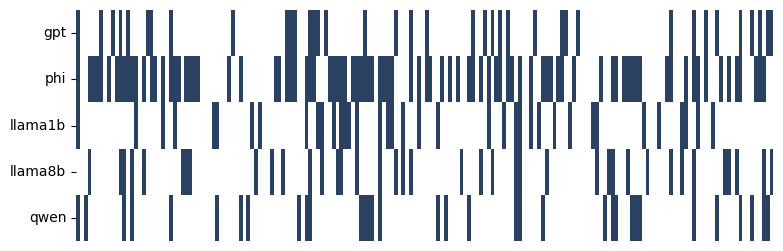

In [81]:
plt.figure(figsize=(9, 3))
sns.heatmap(max_concat_arr, 
            cbar=False, 
            xticklabels=False,
            yticklabels=model_names,
            cmap=ListedColormap(["#FFFFFF", "#2B4162"]), 
            center=0)#, square=True, )
plt.savefig(FIGURES_DIR/"contextuality_barcode_5models.pdf")

# Contextuality Testing

In [82]:
sentence_order_single_results(1, gpt_wp, pnoun_order=0, mode='internal')

{'forward': {'fixed_pnoun': ['him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'him',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   'her',
   '

In [83]:
gpt_wp[2345]['context']['pnoun_order']

['his', 1]